<a href="https://colab.research.google.com/github/Miturazz/Customer-churn-prediction/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Updated working dataset URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Display the first 5 rows to confirm it loaded
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Drop the customerID column as it holds no predictive value
df = df.drop('customerID', axis=1)

# Force 'TotalCharges' to be numeric, turning blank spaces into NaN (missing values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing values (only 11 rows are dropped here)
df = df.dropna()

# Map the target variable (Churn) to 1s and 0s
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Data cleaning complete. Current shape:", df.shape)

Data cleaning complete. Current shape: (7032, 20)


In [9]:
# One-Hot Encoding: turns categorical text columns into binary 0/1 columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features (X) and the target variable (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (5625, 30)
Testing set size: (1407, 30)


In [10]:
# Initialize the model
clf = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
clf.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


Accuracy Score: 0.7754

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407



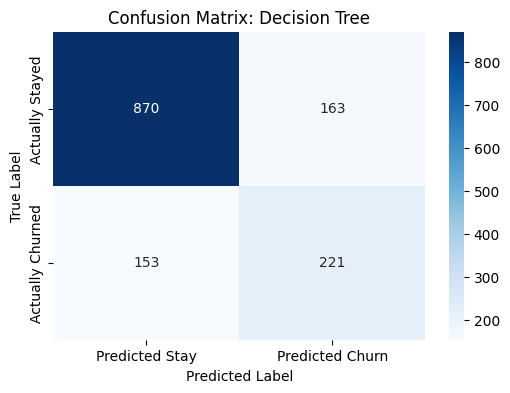

In [11]:
# Make predictions on the test set
y_pred = clf.predict(X_test)

# Print core metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stay', 'Predicted Churn'],
            yticklabels=['Actually Stayed', 'Actually Churned'])
plt.title('Confusion Matrix: Decision Tree')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()